In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
prepared_file_path = r"D:\Data Analytics Project\EduPro_Predictive_Modeling\data\prepared_data\EduPro_Prepared.xlsx"

df = pd.read_excel(
    prepared_file_path,
    sheet_name="Prepared_Data"
)

## Verify the transaction dataset

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Rows: 10000
Columns: 29
Missing values: 0
Duplicate rows: 0


In [4]:
df.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,UserName,UserAge,UserGender,...,TeacherAge,TeacherGender,Expertise,YearsOfExperience,TeacherRating,TransactionYear,TransactionMonth,TransactionDay,TransactionDayOfWeek,TransactionQuarter
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040,morrisonamanda,33,Female,...,49,Male,Cybersecurity,24,4.58,2025,10,25,5,4
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040,morrisonamanda,33,Female,...,49,Male,Cybersecurity,24,4.58,2025,1,13,0,1
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040,morrisonamanda,33,Female,...,49,Male,Cybersecurity,24,4.58,2025,3,28,4,1
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040,fthornton,23,Female,...,49,Male,Cybersecurity,24,4.58,2025,6,2,0,2
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042,fthornton,23,Female,...,49,Female,Machine Learning,21,4.97,2025,8,10,6,3


In [5]:
df.columns.tolist()

['TransactionID',
 'UserID',
 'CourseID',
 'TransactionDate',
 'Amount',
 'PaymentMethod',
 'TeacherID',
 'UserName',
 'UserAge',
 'UserGender',
 'Email',
 'CourseName',
 'CourseCategory',
 'CourseType',
 'CourseLevel',
 'CoursePrice',
 'CourseDuration',
 'CourseRating',
 'TeacherName',
 'TeacherAge',
 'TeacherGender',
 'Expertise',
 'YearsOfExperience',
 'TeacherRating',
 'TransactionYear',
 'TransactionMonth',
 'TransactionDay',
 'TransactionDayOfWeek',
 'TransactionQuarter']

## Create a transaction-specific EDA dataframe

In [6]:
transactions_eda = df.copy()

In [7]:
transactions_eda.shape

(10000, 29)

## Transactions ID validation

In [8]:
print("Unique Transaction IDs:", transactions_eda["TransactionID"].nunique())
print("Duplicate Transaction IDs:", transactions_eda["TransactionID"].duplicated().sum())

Unique Transaction IDs: 10000
Duplicate Transaction IDs: 0


In [9]:
transactions_eda["TransactionID"].isnull().sum()

np.int64(0)

## Transaction date analysis

In [10]:
transactions_eda["TransactionDate"] = pd.to_datetime(
    transactions_eda["TransactionDate"]
)

In [11]:
transactions_eda["TransactionDate"].min()

Timestamp('2025-01-01 00:00:00')

In [12]:
transactions_eda["TransactionDate"].max()

Timestamp('2025-12-30 00:00:00')

In [13]:
transactions_eda["TransactionDate"].describe()

count                         10000
mean     2025-07-01 03:50:32.640000
min             2025-01-01 00:00:00
25%             2025-04-02 00:00:00
50%             2025-06-30 00:00:00
75%             2025-09-28 00:00:00
max             2025-12-30 00:00:00
Name: TransactionDate, dtype: object

## Transactions by year

In [14]:
transactions_by_year = (
    transactions_eda
    .groupby("TransactionYear")
    .size()
    .reset_index(name="TransactionCount")
)

transactions_by_year

,TransactionYear,TransactionCount
0,2025,10000


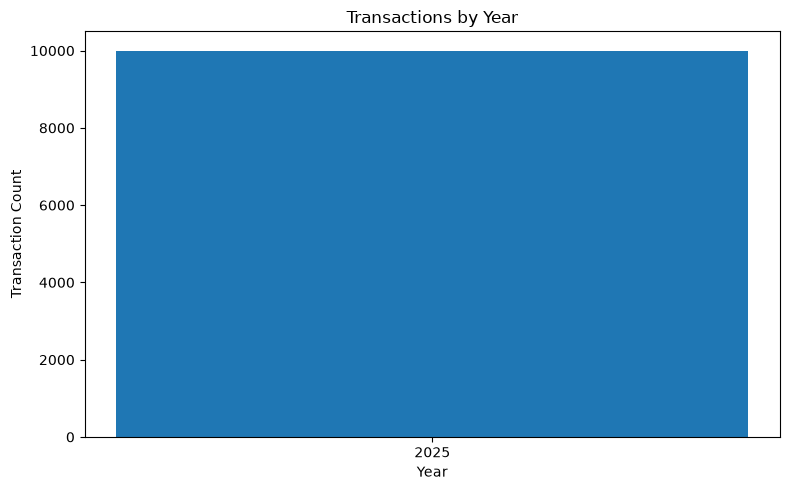

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    transactions_by_year["TransactionYear"].astype(str),
    transactions_by_year["TransactionCount"]
)

plt.title("Transactions by Year")
plt.xlabel("Year")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.show()

## Transactions by months

In [16]:
transactions_by_month = (
    transactions_eda
    .groupby("TransactionMonth")
    .size()
    .reset_index(name="TransactionCount")
    .sort_values("TransactionMonth")
)

transactions_by_month

,TransactionMonth,TransactionCount
0,1,833
1,2,766
2,3,857
3,4,831
4,5,825
5,6,899
6,7,826
7,8,844
8,9,870
9,10,762


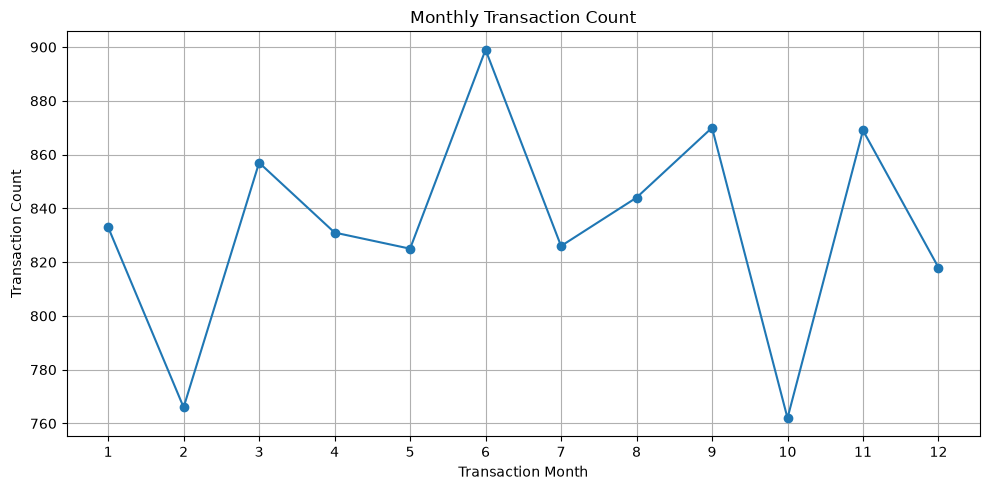

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(
    transactions_by_month["TransactionMonth"],
    transactions_by_month["TransactionCount"],
    marker="o"
)

plt.title("Monthly Transaction Count")
plt.xlabel("Transaction Month")
plt.ylabel("Transaction Count")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

## Transactions by quarter

In [18]:
transactions_by_quarter = (
    transactions_eda
    .groupby("TransactionQuarter")
    .size()
    .reset_index(name="TransactionCount")
    .sort_values("TransactionQuarter")
)

transactions_by_quarter

,TransactionQuarter,TransactionCount
0,1,2456
1,2,2555
2,3,2540
3,4,2449


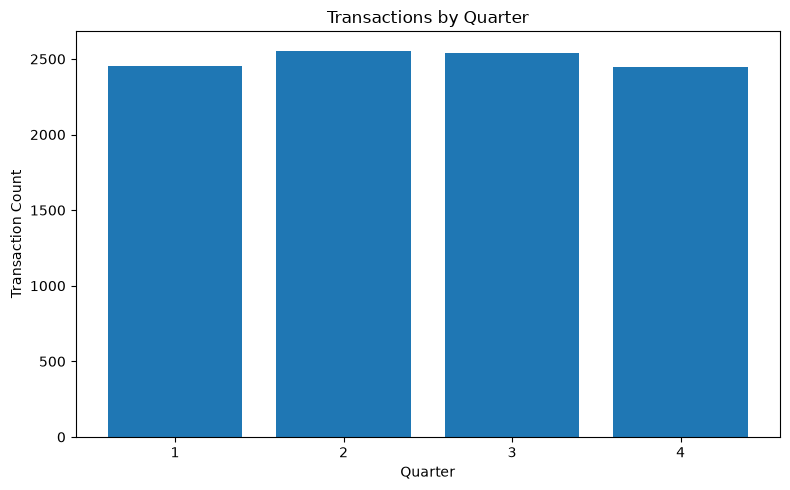

In [19]:
plt.figure(figsize=(8, 5))

plt.bar(
    transactions_by_quarter["TransactionQuarter"].astype(str),
    transactions_by_quarter["TransactionCount"]
)

plt.title("Transactions by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.show()

## Transaction by day of week

In [20]:
transactions_by_day = (
    transactions_eda
    .groupby("TransactionDayOfWeek")
    .size()
    .reset_index(name="TransactionCount")
    .sort_values("TransactionDayOfWeek")
)

transactions_by_day

,TransactionDayOfWeek,TransactionCount
0,0,1378
1,1,1474
2,2,1439
3,3,1488
4,4,1379
5,5,1394
6,6,1448


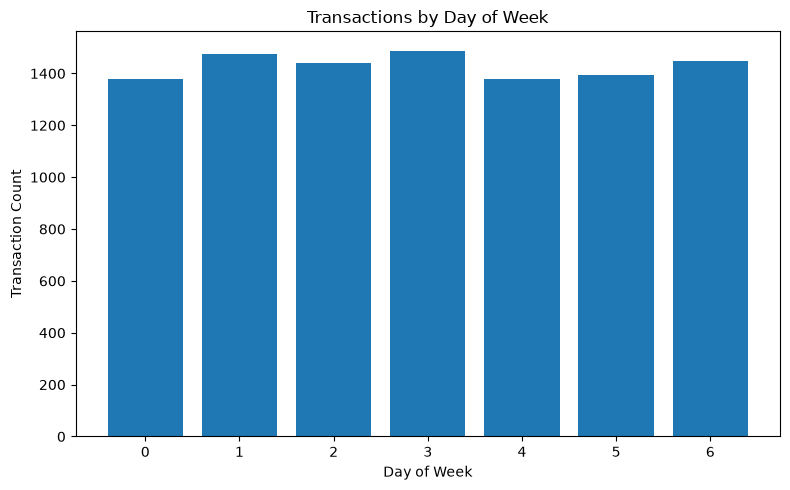

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(
    transactions_by_day["TransactionDayOfWeek"].astype(str),
    transactions_by_day["TransactionCount"]
)

plt.title("Transactions by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.show()

#### Here, Pandas uses:

0 = Monday
1 = Tuesday
2 = Wednesday
3 = Thursday 
4 = Friday
5 = Saturday
6 = Sunday

## Transaction amount statistical analysis

In [22]:
transactions_eda["Amount"].describe()

count    10000.000000
mean        91.132347
std        152.063524
min          0.000000
25%          0.000000
50%          0.000000
75%        119.040000
max        490.900000
Name: Amount, dtype: float64

In [23]:
transactions_eda["Amount"].value_counts().head(20)

Amount
0.00      6403
299.57     192
57.32      178
327.99     174
490.90     174
487.92     173
37.89      171
0.78       171
285.05     168
346.71     167
89.59      166
117.68     166
53.86      166
472.28     164
415.51     163
119.04     161
342.61     158
276.37     156
326.02     151
394.26     150
Name: count, dtype: int64

In [24]:
print("Total Revenue:", transactions_eda["Amount"].sum())
print("Average Transaction Amount:", transactions_eda["Amount"].mean())
print("Median Transaction Amount:", transactions_eda["Amount"].median())
print("Minimum Transaction Amount:", transactions_eda["Amount"].min())
print("Maximum Transaction Amount:", transactions_eda["Amount"].max())

Total Revenue: 911323.47
Average Transaction Amount: 91.132347
Median Transaction Amount: 0.0
Minimum Transaction Amount: 0.0
Maximum Transaction Amount: 490.9


## Zero-value transactions

In [25]:
zero_amount_count = (
    transactions_eda["Amount"] == 0
).sum()

zero_amount_percentage = (
    zero_amount_count /
    len(transactions_eda)
) * 100

print("Zero-amount transactions:", zero_amount_count)
print("Zero-amount percentage:", zero_amount_percentage)

Zero-amount transactions: 6403
Zero-amount percentage: 64.03


In [26]:
transactions_eda[
    transactions_eda["Amount"] == 0
]["CourseType"].value_counts()

CourseType
Free    6403
Name: count, dtype: int64

In [27]:
pd.crosstab(
    transactions_eda["CourseType"],
    transactions_eda["Amount"].eq(0)
)

Amount,False,True
CourseType,,
Free,0,6403
Paid,3597,0


## Free vs Paid Transaction analysis

In [28]:
transactions_eda["CourseType"].value_counts()

CourseType
Free    6403
Paid    3597
Name: count, dtype: int64

In [29]:
course_type_summary = (
    transactions_eda
    .groupby("CourseType")
    .agg(
        TransactionCount=("TransactionID", "count"),
        TotalRevenue=("Amount", "sum"),
        AverageAmount=("Amount", "mean")
    )
    .reset_index()
)

course_type_summary

,CourseType,TransactionCount,TotalRevenue,AverageAmount
0,Free,6403,0.00,0.000000
1,Paid,3597,911323.47,253.356539


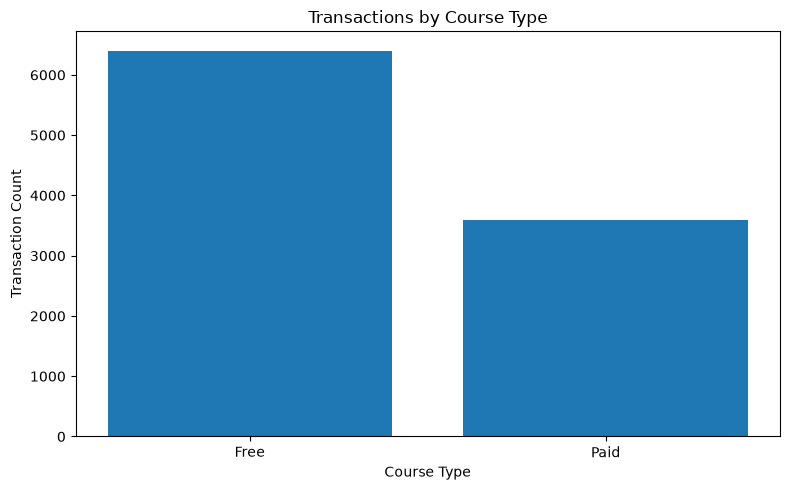

In [30]:
plt.figure(figsize=(8, 5))

plt.bar(
    course_type_summary["CourseType"],
    course_type_summary["TransactionCount"]
)

plt.title("Transactions by Course Type")
plt.xlabel("Course Type")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.show()

## Payment method analysis

In [31]:
payment_summary = (
    transactions_eda
    .groupby("PaymentMethod")
    .agg(
        TransactionCount=("TransactionID", "count"),
        TotalRevenue=("Amount", "sum"),
        AverageAmount=("Amount", "mean")
    )
    .reset_index()
    .sort_values("TransactionCount", ascending=False)
)

payment_summary

,PaymentMethod,TransactionCount,TotalRevenue,AverageAmount
2,PayPal,3389,305580.74,90.168410
1,Credit Card,3333,300690.52,90.216178
0,Bank Transfer,3278,305052.21,93.060467


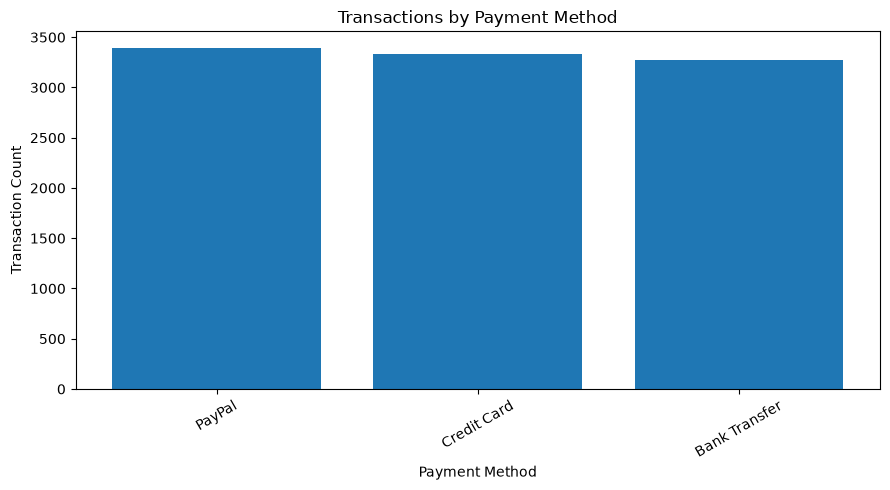

In [32]:
plt.figure(figsize=(9, 5))

plt.bar(
    payment_summary["PaymentMethod"],
    payment_summary["TransactionCount"]
)

plt.title("Transactions by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Transaction Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Revenue by payment method

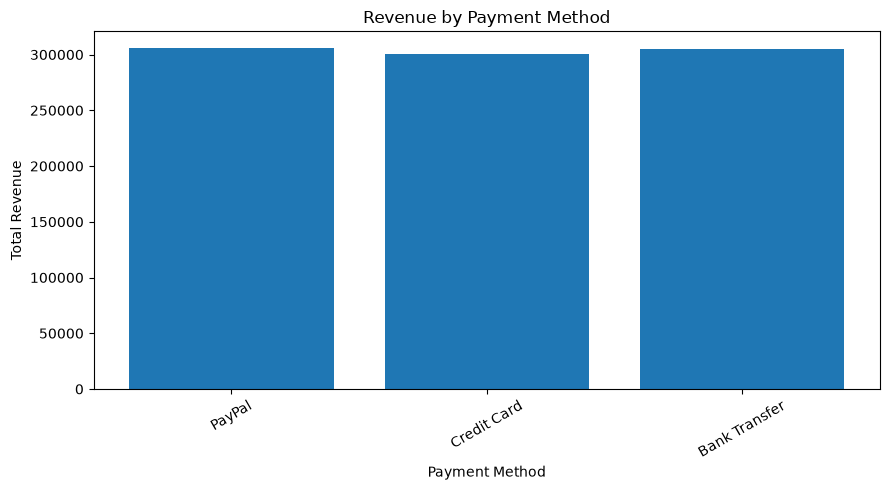

In [33]:
plt.figure(figsize=(9, 5))

plt.bar(
    payment_summary["PaymentMethod"],
    payment_summary["TotalRevenue"]
)

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Transactions by course category

In [34]:
category_transaction_summary = (
    transactions_eda
    .groupby("CourseCategory")
    .agg(
        TransactionCount=("TransactionID", "count"),
        TotalRevenue=("Amount", "sum"),
        AverageAmount=("Amount", "mean")
    )
    .reset_index()
    .sort_values("TransactionCount", ascending=False)
)

category_transaction_summary

,CourseCategory,TransactionCount,TotalRevenue,AverageAmount
3,Data Science,916,77052.32,84.118253
6,Finance,864,28106.20,32.530324
11,Web Development,844,16682.15,19.765581
1,Business,833,181527.58,217.920264
10,Project Management,829,169103.21,203.984572
0,Artificial Intelligence,829,202750.67,244.572581
4,Design,827,43113.72,52.132672
2,Cybersecurity,819,59139.00,72.208791
7,Machine Learning,819,133.38,0.162857
5,Digital Marketing,808,56261.32,69.630347


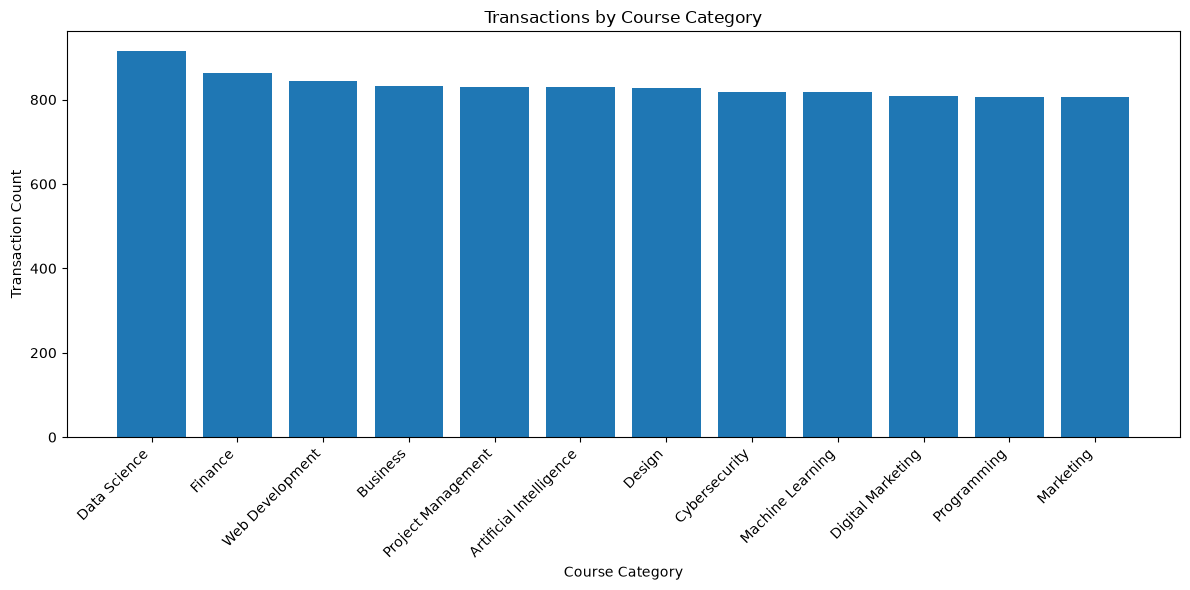

In [35]:
plt.figure(figsize=(12, 6))

plt.bar(
    category_transaction_summary["CourseCategory"],
    category_transaction_summary["TransactionCount"]
)

plt.title("Transactions by Course Category")
plt.xlabel("Course Category")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Revenue by course category

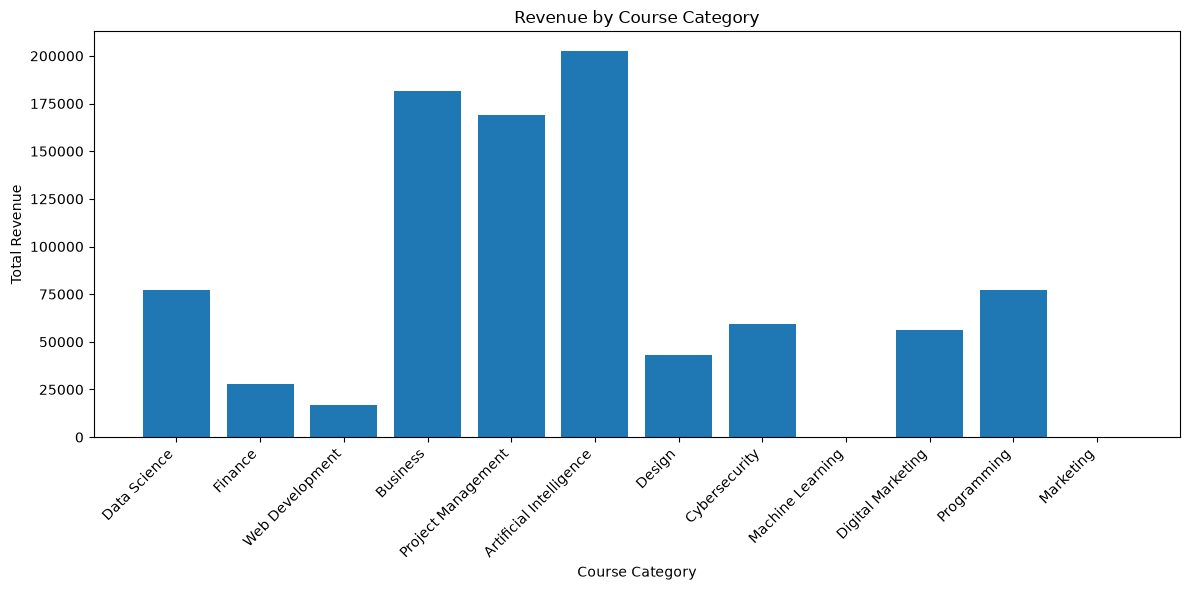

In [36]:
plt.figure(figsize=(12, 6))

plt.bar(
    category_transaction_summary["CourseCategory"],
    category_transaction_summary["TotalRevenue"]
)

plt.title("Revenue by Course Category")
plt.xlabel("Course Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Top courses by transaction count

In [37]:
top_courses_transactions = (
    transactions_eda
    .groupby(["CourseID", "CourseName"])
    .size()
    .reset_index(name="TransactionCount")
    .sort_values("TransactionCount", ascending=False)
)

top_courses_transactions.head(10)

,CourseID,CourseName,TransactionCount
20,CR00021,Data Analysis with Python,196
57,CR00058,Social Media Strategy,194
24,CR00025,Statistical Analysis,192
47,CR00048,AI Ethics,186
22,CR00023,Machine Learning Fundamentals,185
41,CR00042,Investment Strategies,183
42,CR00043,Corporate Finance,182
9,CR00010,3D Modeling,180
34,CR00035,Cyber Threat Intelligence,179
6,CR00007,UI/UX Design,178


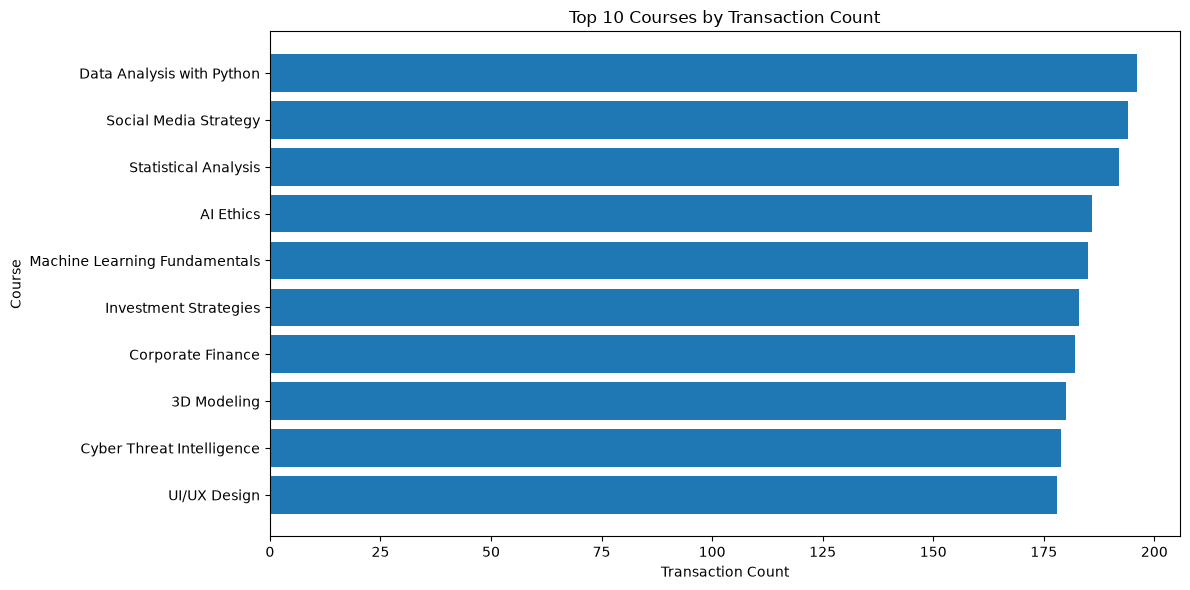

In [38]:
top10 = top_courses_transactions.head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    top10["CourseName"],
    top10["TransactionCount"]
)

plt.title("Top 10 Courses by Transaction Count")
plt.xlabel("Transaction Count")
plt.ylabel("Course")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Top courses by revenue 

In [39]:
top_courses_revenue = (
    transactions_eda
    .groupby(["CourseID", "CourseName"])
    .agg(
        TransactionCount=("TransactionID", "count"),
        TotalRevenue=("Amount", "sum")
    )
    .reset_index()
    .sort_values("TotalRevenue", ascending=False)
)

top_courses_revenue.head(10)

,CourseID,CourseName,TransactionCount,TotalRevenue
49,CR00050,Computer Vision,174,85416.60
11,CR00012,Business Strategy,173,84410.16
0,CR00001,Python Basics,164,77453.92
48,CR00049,Deep Learning,163,67728.13
33,CR00034,Data Encryption,150,59139.00
38,CR00039,Project Planning,167,57900.57
24,CR00025,Statistical Analysis,192,57517.44
39,CR00040,Leadership in Projects,174,57070.26
37,CR00038,Risk Management,158,54132.38
10,CR00011,Entrepreneurship 101,151,49229.02


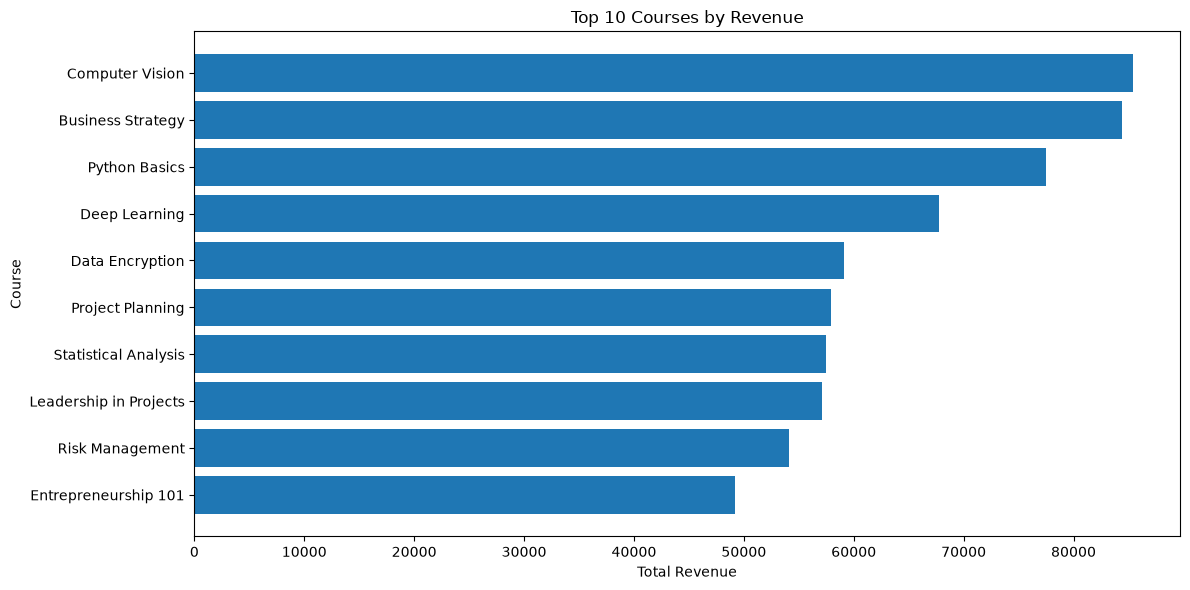

In [40]:
top10_revenue = top_courses_revenue.head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    top10_revenue["CourseName"],
    top10_revenue["TotalRevenue"]
)

plt.title("Top 10 Courses by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Course")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## User transaction analysis

In [41]:
user_transaction_summary = (
    transactions_eda
    .groupby("UserID")
    .agg(
        TransactionCount=("TransactionID", "count"),
        TotalSpent=("Amount", "sum"),
        AverageTransaction=("Amount", "mean")
    )
    .reset_index()
)

user_transaction_summary.describe()

,TransactionCount,TotalSpent,AverageTransaction
count,3000.000000,3000.000000,3000.000000
mean,3.333333,303.774490,89.345012
std,4.352149,482.513859,125.054785
min,1.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000
50%,1.000000,53.860000,26.930000
75%,3.000000,415.510000,133.465000
max,16.000000,3054.370000,490.900000


In [42]:
user_transaction_summary.sort_values(
    "TransactionCount",
    ascending=False
).head(10)

,UserID,TransactionCount,TotalSpent,AverageTransaction
2975,U02976,16,1526.86,95.428750
17,U00018,16,1468.03,91.751875
426,U00427,16,1374.23,85.889375
1202,U01203,16,1827.61,114.225625
2257,U02258,16,1617.15,101.071875
1723,U01724,16,1227.77,76.735625
338,U00339,16,2087.63,130.476875
1336,U01337,16,1242.90,77.681250
1542,U01543,16,1848.28,115.517500
828,U00829,16,1338.31,83.644375


In [43]:
user_transaction_summary.sort_values(
    "TotalSpent",
    ascending=False
).head(10)

,UserID,TransactionCount,TotalSpent,AverageTransaction
378,U00379,14,3054.37,218.169286
2683,U02684,14,2747.30,196.235714
1169,U01170,14,2739.04,195.645714
1653,U01654,15,2711.54,180.769333
880,U00881,16,2703.36,168.960000
1772,U01773,16,2596.54,162.283750
2682,U02683,15,2578.46,171.897333
583,U00584,14,2559.85,182.846429
259,U00260,15,2445.20,163.013333
1283,U01284,15,2437.75,162.516667


## Transaction amount distribution

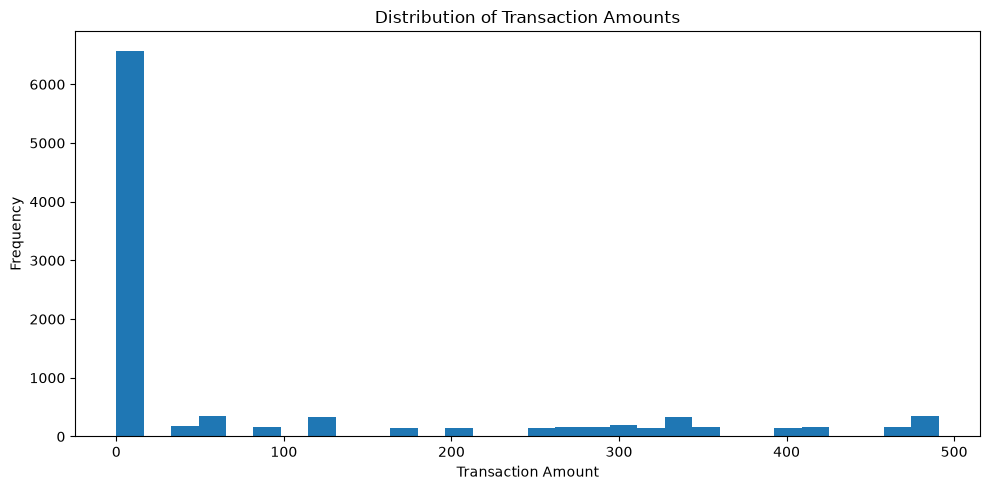

In [44]:
plt.figure(figsize=(10, 5))

plt.hist(
    transactions_eda["Amount"],
    bins=30
)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Boxplot for transaction amounts

C:\Users\tejpr\AppData\Local\Temp\ipykernel_19276\2636728501.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


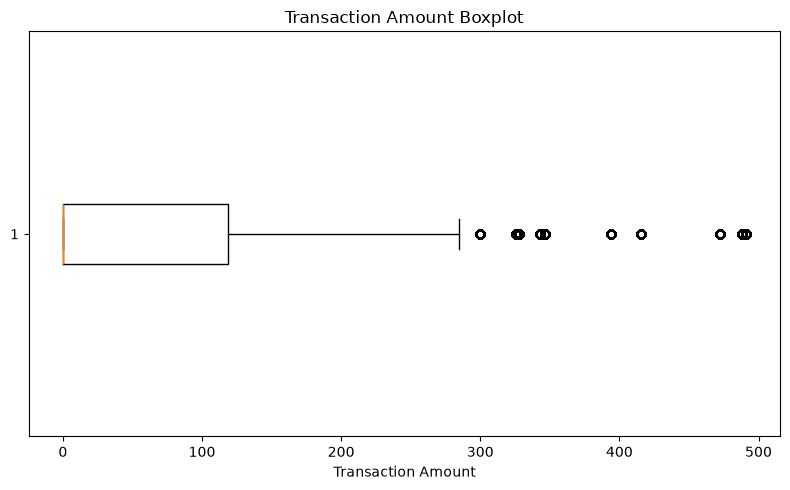

In [45]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    transactions_eda["Amount"],
    vert=False
)

plt.title("Transaction Amount Boxplot")
plt.xlabel("Transaction Amount")
plt.tight_layout()
plt.show()

## MOnthly revenue analyisis

In [46]:
monthly_revenue = (
    transactions_eda
    .groupby("TransactionMonth")["Amount"]
    .sum()
    .reset_index(name="TotalRevenue")
    .sort_values("TransactionMonth")
)

monthly_revenue

,TransactionMonth,TotalRevenue
0,1,83039.70
1,2,66983.84
2,3,81619.62
3,4,78656.48
4,5,72283.85
5,6,80465.73
6,7,72381.81
7,8,67602.50
8,9,81051.05
9,10,71287.01


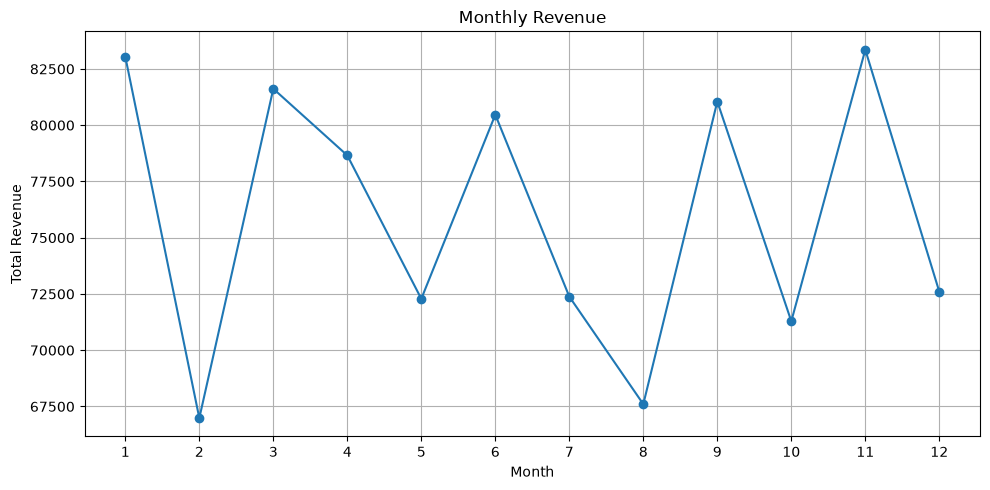

In [47]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_revenue["TransactionMonth"],
    monthly_revenue["TotalRevenue"],
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

## Monthly transactional count vs revenue

In [48]:
monthly_summary = (
    transactions_eda
    .groupby("TransactionMonth")
    .agg(
        TransactionCount=("TransactionID", "count"),
        TotalRevenue=("Amount", "sum"),
        AverageTransactionAmount=("Amount", "mean")
    )
    .reset_index()
    .sort_values("TransactionMonth")
)

monthly_summary

,TransactionMonth,TransactionCount,TotalRevenue,AverageTransactionAmount
0,1,833,83039.70,99.687515
1,2,766,66983.84,87.446266
2,3,857,81619.62,95.238763
3,4,831,78656.48,94.652804
4,5,825,72283.85,87.616788
5,6,899,80465.73,89.505818
6,7,826,72381.81,87.629310
7,8,844,67602.50,80.097749
8,9,870,81051.05,93.162126
9,10,762,71287.01,93.552507


## Correlation analysis

In [49]:
transaction_numeric = transactions_eda[
    [
        "Amount",
        "CoursePrice",
        "CourseDuration",
        "CourseRating",
        "UserAge",
        "TeacherRating",
        "YearsOfExperience",
        "TransactionMonth",
        "TransactionDay",
        "TransactionQuarter"
    ]
]

transaction_numeric.corr()

,Amount,CoursePrice,CourseDuration,CourseRating,UserAge,TeacherRating,YearsOfExperience,TransactionMonth,TransactionDay,TransactionQuarter
Amount,1.000000,1.000000,-0.088745,-0.031465,-0.004630,-0.012513,0.024223,-0.007204,-0.008751,-0.006017
CoursePrice,1.000000,1.000000,-0.088745,-0.031465,-0.004630,-0.012513,0.024223,-0.007204,-0.008751,-0.006017
CourseDuration,-0.088745,-0.088745,1.000000,0.198433,-0.010838,-0.003035,-0.015613,0.000670,0.010446,-0.001883
CourseRating,-0.031465,-0.031465,0.198433,1.000000,-0.003945,-0.001577,-0.007015,-0.009554,-0.007671,-0.009831
UserAge,-0.004630,-0.004630,-0.010838,-0.003945,1.000000,-0.004712,0.002436,0.020713,-0.007953,0.018764
TeacherRating,-0.012513,-0.012513,-0.003035,-0.001577,-0.004712,1.000000,0.845004,-0.008438,0.002829,-0.007674
YearsOfExperience,0.024223,0.024223,-0.015613,-0.007015,0.002436,0.845004,1.000000,-0.000225,0.006181,0.002432
TransactionMonth,-0.007204,-0.007204,0.000670,-0.009554,0.020713,-0.008438,-0.000225,1.000000,0.020822,0.971155
TransactionDay,-0.008751,-0.008751,0.010446,-0.007671,-0.007953,0.002829,0.006181,0.020822,1.000000,0.025544
TransactionQuarter,-0.006017,-0.006017,-0.001883,-0.009831,0.018764,-0.007674,0.002432,0.971155,0.025544,1.000000


In [50]:
transactions_eda[
    ["Amount", "CoursePrice"]
].corr()

,Amount,CoursePrice
Amount,1.0,1.0
CoursePrice,1.0,1.0


In [51]:
transactions_eda[
    ["Amount", "CourseRating"]
].corr()

,Amount,CourseRating
Amount,1.000000,-0.031465
CourseRating,-0.031465,1.000000


In [52]:
transactions_eda[
    ["Amount", "TeacherRating"]
].corr()

,Amount,TeacherRating
Amount,1.000000,-0.012513
TeacherRating,-0.012513,1.000000


## Transaction summary table

In [53]:
transaction_summary = pd.DataFrame({
    "Metric": [
        "Total Transactions",
        "Unique Users",
        "Unique Courses",
        "Unique Teachers",
        "Total Revenue",
        "Average Transaction Amount",
        "Median Transaction Amount",
        "Minimum Transaction Amount",
        "Maximum Transaction Amount"
    ],
    "Value": [
        transactions_eda["TransactionID"].nunique(),
        transactions_eda["UserID"].nunique(),
        transactions_eda["CourseID"].nunique(),
        transactions_eda["TeacherID"].nunique(),
        transactions_eda["Amount"].sum(),
        transactions_eda["Amount"].mean(),
        transactions_eda["Amount"].median(),
        transactions_eda["Amount"].min(),
        transactions_eda["Amount"].max()
    ]
})

transaction_summary

,Metric,Value
0,Total Transactions,10000.000000
1,Unique Users,3000.000000
2,Unique Courses,60.000000
3,Unique Teachers,60.000000
4,Total Revenue,911323.470000
5,Average Transaction Amount,91.132347
6,Median Transaction Amount,0.000000
7,Minimum Transaction Amount,0.000000
8,Maximum Transaction Amount,490.900000


## Final transaction-level validation

In [54]:
print("Transaction rows:", transactions_eda.shape[0])
print("Transaction columns:", transactions_eda.shape[1])
print("Missing values:", transactions_eda.isnull().sum().sum())
print("Duplicate rows:", transactions_eda.duplicated().sum())
print("Unique Transaction IDs:", transactions_eda["TransactionID"].nunique())

Transaction rows: 10000
Transaction columns: 29
Missing values: 0
Duplicate rows: 0
Unique Transaction IDs: 10000


## Saving Transaction works

In [55]:
from pathlib import Path

eda_folder = Path(
    r"D:\Data Analytics Project\EduPro_Predictive_Modeling\data\eda_data"
)

eda_folder.mkdir(
    parents=True,
    exist_ok=True
)

In [56]:
transaction_eda_file_path = (
    eda_folder / "EduPro_Transaction_EDA.xlsx"
)

transaction_eda_file_path

WindowsPath('D:/Data Analytics Project/EduPro_Predictive_Modeling/data/eda_data/EduPro_Transaction_EDA.xlsx')

In [57]:
with pd.ExcelWriter(
    transaction_eda_file_path,
    engine="openpyxl"
) as writer:

    transaction_summary.to_excel(
        writer,
        sheet_name="Transaction_Summary",
        index=False
    )

    monthly_summary.to_excel(
        writer,
        sheet_name="Monthly_Summary",
        index=False
    )

    payment_summary.to_excel(
        writer,
        sheet_name="Payment_Method",
        index=False
    )

    category_transaction_summary.to_excel(
        writer,
        sheet_name="Category_Analysis",
        index=False
    )

    top_courses_transactions.to_excel(
        writer,
        sheet_name="Top_Courses_Transactions",
        index=False
    )

    top_courses_revenue.to_excel(
        writer,
        sheet_name="Top_Courses_Revenue",
        index=False
    )

    user_transaction_summary.to_excel(
        writer,
        sheet_name="User_Transactions",
        index=False
    )

In [58]:
print(
    f"Transaction EDA output saved at:\n"
    f"{transaction_eda_file_path}"
)

Transaction EDA output saved at:
D:\Data Analytics Project\EduPro_Predictive_Modeling\data\eda_data\EduPro_Transaction_EDA.xlsx
